In [1]:
# %% [markdown]
# # lab8: 캡스톤 — Iris 데이터 변분 양자 분류기 (VQC)
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# lab5(인코딩·스케일링) + lab6(최적화) + lab7(ansatz)를 **실데이터·멀티클래스**로 통합한다.
# Iris(특징 4개, 클래스 3개)를 4큐빗 회로로 분류한다.
#
# 회로 = **IQP 인코딩**(특징 사상) + **StronglyEntanglingLayers**(학습 ansatz)
#       → 3개 큐빗의 <Z> 를 클래스 점수로 쓰고 argmax 로 분류.
#
# **학습 목표**
# 1. 실데이터 전처리(MinMax [0,π] 스케일링)와 train/test 분할.
# 2. IQP 인코딩 + SEL ansatz 로 멀티클래스 VQC 구성.
# 3. 배치(벡터화) 비용으로 빠르게 학습 (샘플 루프 대비 100배+).
# 4. (관찰) 스텝 수 ↑ → 정확도, 층 수 ↑ → 과적합 트레이드오프.
#
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane scikit-learn


In [2]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

# ===== 학생 수정 영역 =====
N_LAYERS  = 2       # ansatz 레이어 수 (2 권장, 3/4 로 과적합 관찰)
N_REPEATS = 1       # IQP 반복 횟수 (1/2)
STEPS     = 150     # 학습 스텝 (60=부족, 150=권장)
LR        = 0.05    # 학습률 (Adam)
PLOT_FEAT = [2, 3]  # 결정경계에 쓸 feature 2개
# ==========================

N_QUBITS, N_CLASSES = 4, 3



In [3]:

# %%
# ===========================================================
#  8-1: 데이터 준비 — Iris, MinMax 스케일링, 층화 분할
# ===========================================================
print("=" * 60)
print("lab8-1: Iris 데이터 준비")
print("=" * 60)

iris = load_iris()
scaler = MinMaxScaler((0, std_np.pi))              # 특징을 [0, pi] 로 (lab5 스케일링)
X_scaled = scaler.fit_transform(iris.data)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, iris.target, test_size=0.3, stratify=iris.target, random_state=42
)
X_train, X_test = np.array(X_train), np.array(X_test)

print(f"\n  특징: {iris.feature_names}")
print(f"  클래스: {list(iris.target_names)}")
print(f"  train {len(X_train)}개 / test {len(X_test)}개,  입력 형상 {X_train.shape}")



lab8-1: Iris 데이터 준비

  특징: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  클래스: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  train 105개 / test 45개,  입력 형상 (105, 4)



lab8-2: 양자 회로 (IQP + SEL)

  파라미터 형상 (2, 4, 3) -> 24개


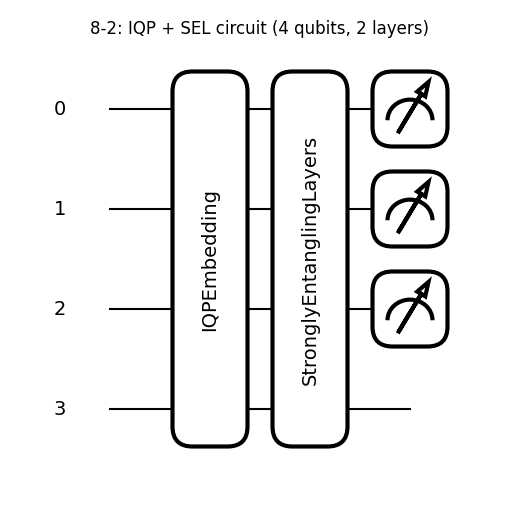

In [4]:

# %%
# ===========================================================
#  8-2: 회로 — IQP 인코딩 + StronglyEntanglingLayers
# ===========================================================
print("\n" + "=" * 60)
print("lab8-2: 양자 회로 (IQP + SEL)")
print("=" * 60)

dev = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev)
def circuit(x, w):
    qml.IQPEmbedding(x, wires=range(N_QUBITS), n_repeats=N_REPEATS)   # 인코딩(고정)
    qml.StronglyEntanglingLayers(w, wires=range(N_QUBITS))            # ansatz(학습)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_CLASSES)]      # 3개 클래스 점수


w_shape = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
n_params = int(std_np.prod(w_shape))
print(f"\n  파라미터 형상 {w_shape} -> {n_params}개")

w_demo = np.array(std_np.random.normal(0, 0.1, w_shape))
fig, ax = qml.draw_mpl(circuit, decimals=2, style="black_white")(X_train[0], w_demo)
fig.suptitle(f"8-2: IQP + SEL circuit ({N_QUBITS} qubits, {N_LAYERS} layers)", fontsize=12)
plt.tight_layout()
plt.show()



In [5]:

# %%
# ===========================================================
#  8-3: 배치 비용 함수 & 학습
# ===========================================================
print("\n" + "=" * 60)
print("lab8-3: 학습 (배치 비용)")
print("=" * 60)


def one_hot(y_arr):
    oh = std_np.zeros((len(y_arr), N_CLASSES))
    oh[std_np.arange(len(y_arr)), y_arr] = 1.0
    return oh


T_train = np.array(2 * one_hot(y_train) - 1)   # 타깃: 정답 클래스 +1, 나머지 -1


def cost(w):
    # 핵심: X_train 전체를 '한 번에' 통과 (브로드캐스팅) -> 샘플 루프 대비 100배+ 빠름
    outs = np.stack(circuit(X_train, w), axis=1)   # (n_samples, 3)
    return np.mean((outs - T_train) ** 2)


def predict(X, w):
    outs = np.stack(circuit(X, w), axis=1)
    return std_np.argmax(std_np.array(outs), axis=1)


std_np.random.seed(42)
w = np.array(std_np.random.normal(0, 0.1, w_shape), requires_grad=True)
opt = qml.AdamOptimizer(LR)

loss_hist, tr_hist, te_hist = [], [], []
for step in range(STEPS):
    w, loss = opt.step_and_cost(cost, w)
    loss_hist.append(float(loss))
    tr_hist.append(float(std_np.mean(predict(X_train, w) == y_train)))
    te_hist.append(float(std_np.mean(predict(X_test, w) == y_test)))
    if step % 30 == 0 or step == STEPS - 1:
        print(f"  step {step:3d}:  loss={loss_hist[-1]:.4f}  train={tr_hist[-1]:.3f}  test={te_hist[-1]:.3f}")




lab8-3: 학습 (배치 비용)
  step   0:  loss=1.0007  train=0.533  test=0.422
  step  30:  loss=0.7109  train=0.762  test=0.711
  step  60:  loss=0.6141  train=0.838  test=0.867
  step  90:  loss=0.5586  train=0.886  test=0.889
  step 120:  loss=0.5553  train=0.886  test=0.889
  step 149:  loss=0.5524  train=0.895  test=0.911



lab8-4: 최종 결과

  train Acc = 0.8952
  test  Acc = 0.9111
  파라미터 24개, 150 스텝
  => 스텝을 늘리면 정확도가 오른다 (60스텝이면 부족, 150이면 수렴).


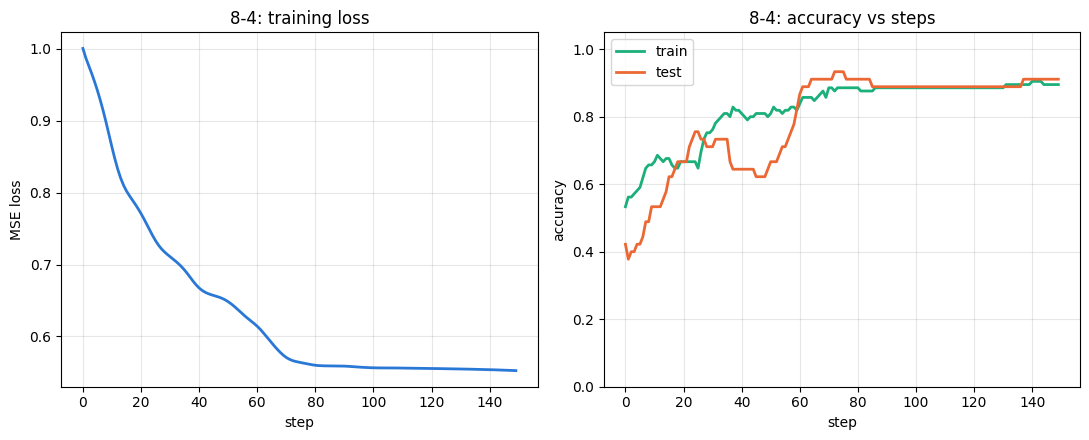


lab8-5: 결정 경계 시각화


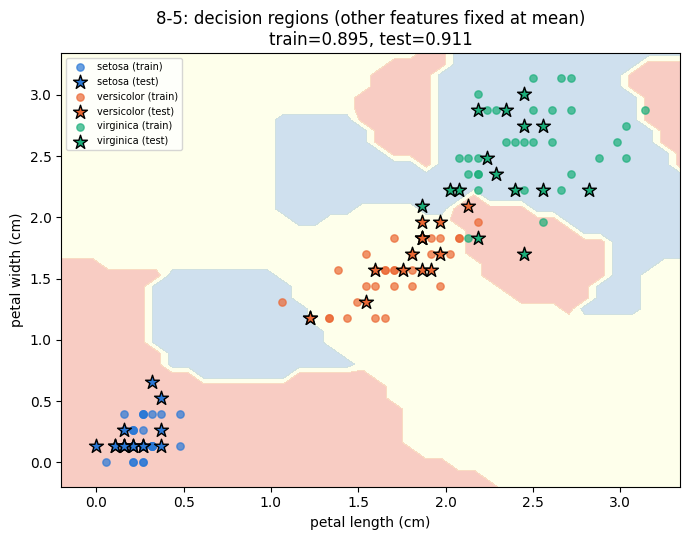

In [6]:

# %%
# ===========================================================
#  8-4: 결과 — 손실과 정확도(스텝에 따른) 곡선
# ===========================================================
print("\n" + "=" * 60)
print("lab8-4: 최종 결과")
print("=" * 60)
print(f"\n  train Acc = {tr_hist[-1]:.4f}")
print(f"  test  Acc = {te_hist[-1]:.4f}")
print(f"  파라미터 {n_params}개, {STEPS} 스텝")
print("  => 스텝을 늘리면 정확도가 오른다 (60스텝이면 부족, 150이면 수렴).")

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4.5))
a.plot(loss_hist, color="#2a78d6", lw=2)
a.set_xlabel("step"); a.set_ylabel("MSE loss"); a.set_title("8-4: training loss")
a.grid(alpha=0.3)
b.plot(tr_hist, color="#1baf7a", lw=2, label="train")
b.plot(te_hist, color="#eb6834", lw=2, label="test")
b.set_ylim(0, 1.05); b.set_xlabel("step"); b.set_ylabel("accuracy")
b.set_title("8-4: accuracy vs steps"); b.legend(); b.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# %%
# ===========================================================
#  8-5: 결정 경계 (선택한 2 feature, 나머지는 평균 고정)
# ===========================================================
print("\n" + "=" * 60)
print("lab8-5: 결정 경계 시각화")
print("=" * 60)

f0, f1 = PLOT_FEAT
means = std_np.mean(X_scaled, axis=0)
gx, gy = std_np.meshgrid(
    std_np.linspace(X_scaled[:, f0].min() - 0.2, X_scaled[:, f0].max() + 0.2, 40),
    std_np.linspace(X_scaled[:, f1].min() - 0.2, X_scaled[:, f1].max() + 0.2, 40),
)
grid = std_np.tile(means, (gx.size, 1))
grid[:, f0] = gx.ravel()
grid[:, f1] = gy.ravel()
Z = predict(np.array(grid), w).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.3, cmap="RdYlBu")
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
for c, (name, col) in enumerate(zip(iris.target_names, colors)):
    m_tr, m_te = y_train == c, y_test == c
    ax.scatter(X_train[m_tr, f0], X_train[m_tr, f1], c=col, s=28, alpha=0.7, label=f"{name} (train)")
    ax.scatter(X_test[m_te, f0], X_test[m_te, f1], c=col, marker="*", s=110,
               edgecolors="black", label=f"{name} (test)")
ax.set_xlabel(iris.feature_names[f0]); ax.set_ylabel(iris.feature_names[f1])
ax.set_title(f"8-5: decision regions (other features fixed at mean)\ntrain={tr_hist[-1]:.3f}, test={te_hist[-1]:.3f}")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()




lab8-6: 층 수를 늘리면 좋아질까? (과적합 관찰)
  layers=2 (params 24):  train=0.895  test=0.911  gap=-0.016
  layers=3 (params 36):  train=0.933  test=0.867  gap=+0.067
  layers=4 (params 48):  train=0.952  test=0.822  gap=+0.130
  => 층을 늘려도 test 는 오르지 않고 train-test 격차(과적합)만 커진다.
     '표현력↑ ≠ 성능↑' — 작은 데이터엔 단순한 ansatz가 유리 (lab7 트레이드오프).


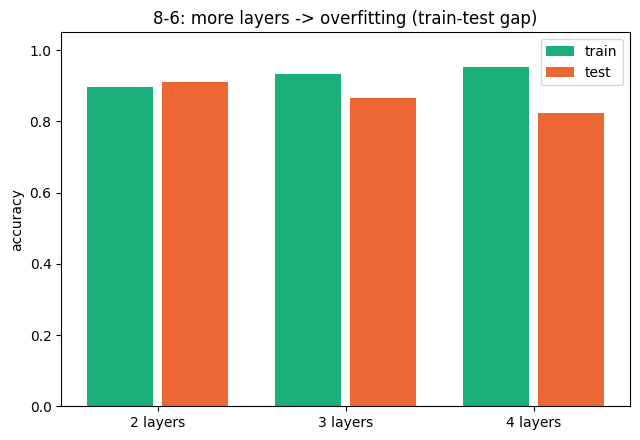

In [7]:

# %%
# ===========================================================
#  8-6: (관찰) 층 수 vs 과적합
# ===========================================================
print("\n" + "=" * 60)
print("lab8-6: 층 수를 늘리면 좋아질까? (과적합 관찰)")
print("=" * 60)


def train_config(layers, steps=STEPS, reps=N_REPEATS, lr=LR):
    dv = qml.device("default.qubit", wires=N_QUBITS)

    @qml.qnode(dv)
    def circ(x, ww):
        qml.IQPEmbedding(x, wires=range(N_QUBITS), n_repeats=reps)
        qml.StronglyEntanglingLayers(ww, wires=range(N_QUBITS))
        return [qml.expval(qml.PauliZ(i)) for i in range(N_CLASSES)]

    sh = qml.StronglyEntanglingLayers.shape(layers, N_QUBITS)

    def cst(ww):
        return np.mean((np.stack(circ(X_train, ww), axis=1) - T_train) ** 2)

    def prd(X, ww):
        return std_np.argmax(std_np.array(np.stack(circ(X, ww), axis=1)), axis=1)

    std_np.random.seed(42)
    ww = np.array(std_np.random.normal(0, 0.1, sh), requires_grad=True)
    o = qml.AdamOptimizer(lr)
    for _ in range(steps):
        ww, _ = o.step_and_cost(cst, ww)
    return (float(std_np.mean(prd(X_train, ww) == y_train)),
            float(std_np.mean(prd(X_test, ww) == y_test)),
            int(std_np.prod(sh)))


layer_list = [2, 3, 4]
tr_accs, te_accs = [], []
for L in layer_list:
    tr, te, p = train_config(L)
    tr_accs.append(tr); te_accs.append(te)
    print(f"  layers={L} (params {p}):  train={tr:.3f}  test={te:.3f}  gap={tr-te:+.3f}")
print("  => 층을 늘려도 test 는 오르지 않고 train-test 격차(과적합)만 커진다.")
print("     '표현력↑ ≠ 성능↑' — 작은 데이터엔 단순한 ansatz가 유리 (lab7 트레이드오프).")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = std_np.arange(len(layer_list))
ax.bar(x - 0.2, tr_accs, 0.35, color="#1baf7a", label="train")
ax.bar(x + 0.2, te_accs, 0.35, color="#eb6834", label="test")
ax.set_xticks(x); ax.set_xticklabels([f"{L} layers" for L in layer_list])
ax.set_ylim(0, 1.05); ax.set_ylabel("accuracy")
ax.set_title("8-6: more layers -> overfitting (train-test gap)")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:

# %% [markdown]
# ## 정리
# - VQC = 인코딩(IQP) + ansatz(SEL, 학습) + 측정(argmax) + 최적화(Adam).
# - **배치 비용**으로 학습이 100배+ 빨라진다 (샘플 루프 금지).
# - **스텝**을 충분히(≈150) 줘야 수렴한다 (test ≈ 0.9).
# - **층 수**를 늘리면 표현력은 커지지만 작은 데이터에선 과적합 → 성능 저하.
#
# **다음(양자 커널 본론)**: 여기 IQP 인코딩으로 만든 상태들의 '겹침(fidelity)'을
# 재면 그것이 양자 커널이며, 변분 학습 대신 커널 SVM 으로 분류할 수 있다.